# Bandits!
by Kiana Alessandra V. Villaera

A manual implementation of Multi-Armed Bandits and its many variants over configurable game constraints.

This notebook serves as an easy way to experiment with different MAB algorithms and game constraints. Everything from reward distribution, number of dominant arms per state, stationarity, and others are configurable

Additionally, the Agent classes are written in such a way that it is intuitive. The only libraries used are your common Data Science staples like `numpy`, `random`, `pandas`, and `matplotlib`.

Agent classes are written with an obvious pattern. They all use the same methods. The only difference between them is what happens within those methods.

Truly, the notebook is a mental exercise more than anything.

Concepts can be found in this book: [Mastering Reinforcement Learning with Python: Build next-generation, self-learning models using reinforcement learning techniques and best practices](https://www.amazon.com/dp/B08M3ZF7Z8?ref=ppx_yo2ov_dt_b_fed_digi_asin_title_351)

## Running the notebook

1. As per usual, run `pip install -r requirements.txt`
2. Notebook should run from top to bottom without issue.
3. Configure the experiment settings by fiddling with the hyperparameters listed under **Game Constraints**

## Introduction

The following notebook is an experimental notebook that focuses on some of the fundamental concepts of Reinforcement Learning. Specifically, Multi-Armed Bandits and Contextual Bandits.

This notebook was created during a weekend wherein the author was desperately missing the feeling of coding and analysis typical of Data Science. She also felt nostalgic about her college thesis on [Temporal Difference Learning with the game 2048](https://ieeexplore.ieee.org/document/6932907). She is currently looking for the soft copy of her transcript...

Agents are manually defined. The only libraries used were `numpy`, `random`, `matplotlib`, and `pandas`. This is a mental exercise more than anything.

For Agent 6, it uses `VowpalWabbit` and is used as a benchmark to test the hand-coded Agents against industry standards.

There are 6 different agents:
1. `RandomAgent` - This guy just vibes. He does not reason. His performance represents the baseline.
2. `EpsilonGreedyBandit` - An implementation of the Epsilon-Greedy Bandit. He's a smart guy.
3. `UCB` - Builds on EGB by replacing random exploration with upper confidence bounds — no epsilon needed.
4. `ThompsonSampling` - Builds on UCB by replacing confidence bounds with Bayesian probability distributions. Instead of asking *"how uncertain am I?"*, it asks *"what's the probability this arm is the best?"*
5. `ContextualBandit` - An implementation of the Contextual Bandit. He's an even smarter guy. He has developed the power of Emotional Intelligence, because he accounts for context.
6. `VowpalWabbit` - This uses a library called [VowpalWabbit](https://vowpalwabbit.org). This is the industry standard I want to pit the above against.

The notebook also compares Agent performance across the above methods.

## Game Constraints

The game has several configurations. You may set the following hyperparameters:

1. `scramble_step` - If set to -1, the game is stationary. Otherwise, all state rewards will be regenerated at every time step as indicated. 
2. `max_iter` - Maximum iterations
3. `num_states` - Total number of states
4. `reward_dist_width` - Total number of reward values per state
5. `num_games_to_play` - Number of games to generate. Note that new states are generated for every game.
6. `reward_dist_mode` - Dictates what kind of reward distribution each state has. This will certainly affect behavior.
7. `epsilon` - Rate of exploration.
8. `alpha` - Discount rate. How much weight is put on more recent moves. Helps keep exploration dynamic especially in non-stationary games.
9. `uncertainty` - Uncertainty $c$ as seen in the formula for UCB indicated in the proceeding cells.
10. `gamma` - Discount rate for ThompsonSampling. If the game is staionary, set `gamma` = 1. If you do not do this, the Agent will fight against recent history which may impede convergence.

Note that some hyperparameters are lists, like `Epsilon`, for example. This is because we search for the best configuration. Essentially, we do a grid search over these parameters. We are doing hyperparameter tuning.


## States
A state only has 3 features:
1. `id` - Some integer that represents a unique state
1. `possible_paths` - List of all the next possible states you can get to from this current state S
2. `reward_action_mapping` - Mapping of the reward signal you will get if you transition to any of the possible next states

When we run `generate_states`, we randomly generate possible paths for each state wherein the minimum is 50 and the maximum is the total number of states.

Note that if `scramble_step` is greater than 1, this means that all states will generate new reward values at the indicated time step. This will give the game an element of non-stationarity. Otherwise, if `scramble_step` is set to -1, then the reward values for all states will be static throughout the game--making it stationary.

## Agent Comparison

| Agent | Exploration Strategy | Uses Context? | Key Hyperparameter | Best For |
|---|---|---|---|---|
| `RandomAgent` | Pure random | No | — | Baseline only |
| `EpsilonGreedyBandit` | Random with prob $\varepsilon$ | No | $\varepsilon$, $\alpha$ | Simple, interpretable environments |
| `UCB` | Confidence bound | No | $c$ | Stationary/non-stationary; no randomness in selection |
| `ThompsonSampling` | Bayesian sampling | No | — | Binary reward settings; naturally adaptive |
| `ContextualBandit` | Confidence bound on context | Yes | $\alpha$ | Personalized decisions with rich feature context |
| `VowpalWabbit` | Industry-optimized | Yes | — | Production benchmark |


## Production Strategies
There are 3 strategies for production:
1. One global bandit - Takes into account all users actions. Recommendations end up being the same. Simple, cheap, but highly impersonal. Ideal for use cases like gaming.
2. One bandit per user - Highly personalized but expensive. Ideal for use cases like music/movie/social media feed recommendations.
3. Segmented bandits - Requires customer segmentation initially, then assign a bandit per segment. A balance between the above 2 approaches. Ideal for the same use cases as #2.

However, for contextual bandits, if a rich user embedding as the context vector exists — it can achieve highly personalized results even if the production strategy is not #2.

## Good Reads

1. [Reinforcement Learning for Machine Learning Model Deployment: Evaluating Multi-Armed Bandits in MLOps Environments](https://arxiv.org/abs/2503.22595)
2. [Offline Policy Evaluation: Run fewer, better A/B tests](https://edoconti.medium.com/offline-policy-evaluation-run-fewer-better-a-b-tests-60ce8f93fa15)
3. [Sample code for CB](https://github.com/uguryi/contextual_bandit/blob/main/ab_vs_mab_vs_cb.ipynb)
4. [Mastering Reinforcement Learning with Python: Build next-generation, self-learning models using reinforcement learning techniques and best practices](https://www.amazon.com/dp/B08M3ZF7Z8?ref=ppx_yo2ov_dt_b_fed_digi_asin_title_351)


In [1]:
import numpy as np
import random as rdm
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class State:
    """A state in this case is very simple. The rewards
        are defined by the next state it will go to. This definition can change,
        it will most certainly result in different behavior.
    """
    def __init__(self, id, reward_dist_type='random', rng=None):
        self.id = id
        self.reward_dist_type = reward_dist_type
        self.rng = rng if rng is not None else np.random.default_rng()

    def possible_paths(self, paths):
        self.possible_paths = paths

    def set_action_reward_mapping(self, action_reward_mapping):
        self.action_reward_mapping = action_reward_mapping

    def get_reward(self, previous_state):
        return self.action_reward_mapping[previous_state]

    def _sample_rewards(self, n):
        rng = self.rng
        if self.reward_dist_type == 'random':
            return np.array([rdm.uniform(-1.0, 1.0) for _ in range(n)])
        elif self.reward_dist_type == 'gaussian':
            return np.clip(rng.normal(loc=0.0, scale=0.5, size=n), -1, 1)
        elif self.reward_dist_type == 'skewed_positive':
            return rng.beta(a=5, b=2, size=n) * 2 - 1
        elif self.reward_dist_type == 'skewed_negative':
            return rng.beta(a=2, b=5, size=n) * 2 - 1
        elif self.reward_dist_type == 'bimodal':
            return np.clip(np.where(
                rng.random(n) < 0.5,
                rng.normal(loc=-0.3, scale=0.15, size=n),  # bad cluster closer to 0
                rng.normal(loc= 0.7, scale=0.15, size=n)   # good cluster stays high
            ), -1, 1)
        elif self.reward_dist_type == 'sparse':
            return np.where(
                rng.random(n) < 0.1,
                rng.uniform(0.8, 1.0, size=n),
                np.zeros(n)
            )
        elif self.reward_dist_type == 'heavy_tailed':
            return np.clip(rng.standard_cauchy(size=n) * 0.1, -1, 1)
        elif self.reward_dist_type == 'constant':
            return np.full(n, fill_value=rdm.uniform(-1.0, 1.0))
        else:
            raise ValueError(f"Unknown reward_dist_type: '{self.reward_dist_type}'")

    def shuffle_action_reward_mapping(self):
        num_rewards = len(self.action_reward_mapping[self.possible_paths[0]])
        self.action_reward_mapping = {
            p: self._sample_rewards(num_rewards)
            for p in self.possible_paths
        }


In [3]:
def describe_the_game(states):
    """Output statistics on the game"""
    num_states = len(states)
    num_paths = 0
    reachable_states = set()

    for s in states:
        num_paths += len(states[s].possible_paths)
        # collect all states that are reachable from any state
        for path in states[s].possible_paths:
            reachable_states.add(path)

    num_reachable_states = len(reachable_states)

    sample_reward_distribution = next(iter(states[0].action_reward_mapping.values()))
    reward_dist_width = len(sample_reward_distribution)

    x = range(0, len(sample_reward_distribution))
    y = sample_reward_distribution

    df = pd.DataFrame([{
        'Number of States': num_states,
        'Number of Reachable States': num_reachable_states,
        'Number of Paths': num_paths,
        'Reward Distribution Width': reward_dist_width
    }])

    plt.figure()
    plt.scatter(x, y, color='green')
    plt.title("Sample Reward Distribution")
    plt.xlabel("Number")
    plt.ylabel("Reward")
    plt.show()

    return df


def generate_states(num=10, reward_dist_type='random', max_number_of_rewards=20):
    """Generate the states"""
    states = {}
    rng = np.random.default_rng()  # use numpy rng for consistency with State

    for n in range(-1, num):
        states[n] = None

    for n in range(-1, num):
        action_reward_mapping = {}

        # initialize the State object
        temp = State(n, reward_dist_type=reward_dist_type, rng=rng)

        # identify the ids of the other States
        other_states = set(states.keys())
        other_states.remove(n)

        # generate possible paths
        if n == -1:
            number_of_possible_paths = rdm.randint(10, num)
        else:
            number_of_possible_paths = rdm.randint(10, num)

        # for each possible path, randomly assign any of the other states
        chosen_other_states = rdm.sample(
            sorted(other_states),
            k=min(number_of_possible_paths, len(other_states))
        )

        temp.possible_paths = list(chosen_other_states)

        # delegate reward sampling to State._sample_rewards()
        for m in chosen_other_states:
            action_reward_mapping[m] = temp._sample_rewards(max_number_of_rewards)

        # inject dominant arms — clearly better than all others
        num_dominant = 1
        dominant_arms = rdm.sample(chosen_other_states, k=num_dominant)
        for arm in dominant_arms:
            action_reward_mapping[arm] = np.full(max_number_of_rewards, fill_value=0.8)

        temp.set_action_reward_mapping(action_reward_mapping)
        states[n] = temp

    return states

## RandomAgent
This agent has absolutely no intelligence whatsoever. It picks randomly from the next possible states.

In [4]:
class RandomAgent:
    """This dude is just living off of vibes"""

    def __init__(self, initial_state):
        """Initialize current state, total reward, and game over flag"""
        self.current_state = initial_state
        self.total_reward = 0
        self.game_over = False

    def move(self, all_states):
        """Determine next state and update total reward"""
        # determine all possible paths
        possible_next_states = self.current_state.possible_paths

        # check if no more possible moves
        if len(possible_next_states) == 0:
            print("No more possible moves!")
            self.game_over = True
            return

        # randomly pick a possible move
        rdm.shuffle(possible_next_states)

        # get next state
        next_state = all_states[rdm.sample(sorted(possible_next_states), k=1)[0]]

        # add reward
        reward = self.current_state.get_reward(next_state.id)
        self.total_reward += rdm.sample(sorted(reward), k=1)[0]

        # move states
        self.current_state = next_state
        return

## EpsilonGreedyBandit
This agent follows the [Epsilon-greedy strategy](https://www.reinforcementlearningpath.com/epsilon-greedy) characterized by balancing exploration (trying new actions) and exploitation (choosing the best-known action). `Epsilon` dictates how likely the Agent is to explore/exploit. A higher Epsilon signals that the agent is more likely to explore. Conversely, a lower `Epsilon` signals that the agent is more likely to play it safe and choose the best known action at the moment.

Optimizing the `EpsilonGreedyBandit` is largely dependent on the `Epsilon` and number of iterations. Whether a more conservative `Agent` or daring `Agent` performs better also depends on the game itself. In this case, the game is almost completely random, so we expect varying levels of behavior.

#### Incremental Mean Update

$$Q_n = Q_{n-1} + \alpha \left( r_n - Q_{n-1} \right)$$

where:
- $Q_n$ — estimated reward value after the current update
- $Q_{n-1}$ — estimated reward value before the current update
- $r_n$ — reward received on the $n$-th pull
- $\alpha \in (0, 1]$ — learning rate; controls how much the new reward influences the estimate

#### What $\alpha$ does

The term $(r_n - Q_{n-1})$ is the **prediction error** — the gap between what you expected and what you actually got. $\alpha$ controls how aggressively you close that gap:

| $\alpha$ value | Behavior |
|---|---|
| $\alpha = \frac{1}{n}$ | Equivalent to a true running average — all past rewards weighted equally |
| High $\alpha$ (e.g. `0.9`) | Recent rewards matter much more — fast to adapt, but forgetful of the past |
| Low $\alpha$ (e.g. `0.01`) | Past rewards matter more — stable estimates, but slow to adapt |
| $\alpha = 1$ | Estimate is always just the last reward — no memory at all |

The key difference from $\frac{1}{n}$ is that a fixed $\alpha$ never "locks in" — even after thousands of pulls, a new reward can still meaningfully shift the estimate. This makes fixed $\alpha$ better suited for **non-stationary environments** where the true reward distribution changes over time.

The game in this notebook is non-stationary — meaning even the reward distribution per state is dynamic. This is because it is designed in such a way that once an Agent takes an action on state `S`, it updates the reward distribution accordingly.

#### Arm Selection Policy

$$a_t = \begin{cases} \text{random arm} & \text{with probability } \varepsilon \\ \arg\max_{a} \, Q(a) & \text{with probability } 1 - \varepsilon \end{cases}$$

where:
- $a_t$ — arm selected at time step $t$
- $\varepsilon$ — exploration rate; probability of choosing a random arm
- $Q(a)$ — current estimated reward value of arm $a$
- $\arg\max_{a}$ — the arm $a$ that maximizes $Q(a)$

In [5]:
class EpsilonGreedyBandit:
    """An implementation of EGB"""

    def __init__(self, num_states, initial_state, epsilon, alpha):
        """Initialize current state, total reward, and game over flag"""
        self.current_state = initial_state
        self.total_reward = 0
        self.game_over = False
        self.epsilon = epsilon
        self.alpha = alpha
        self.arms_count = [0] * num_states
        self.arms_value = [0] * num_states

    def choose_arm(self, possible_next_states):
        """Choose an arm, decide between exploitation and exploration"""

        exploitation_decider = np.random.rand()
        filtered_values = {state: self.arms_value[state] for state in possible_next_states}

        # explore or exploit
        if not np.any(np.array(self.arms_value)):
            # if no history exists
            rdm.shuffle(possible_next_states)
            next_state_id = possible_next_states[0]
        elif exploitation_decider < self.epsilon:
            next_state_id = int(np.random.choice(possible_next_states))
        else:
            next_state_id = max(filtered_values, key=filtered_values.get)

        return next_state_id
    
    def update(self, next_state_id, all_states):
        """Update arms_count, arms_value, and total_reward to keep track"""
        reward = self.current_state.get_reward(next_state_id)
        reward = float(rdm.sample(sorted(reward), k=1)[0])
        self.total_reward += reward

        # get random value from the reward distribution of the next state
        value = self.arms_value[next_state_id]
        n = self.arms_count[next_state_id]
        
        self.arms_count[next_state_id] += 1
        if n > 0:
            self.arms_value[next_state_id] = value + (reward - value) * self.alpha
        else:
            self.arms_value[next_state_id] = value
    
        return all_states[next_state_id]


    def move(self, all_states):
        """Determine next state and update total reward"""
        # determine all possible paths
        possible_next_states = self.current_state.possible_paths

        # check if no more possible moves
        if len(possible_next_states) == 0:
            self.game_over = True
            return
        
        # choose next state
        next_state_id = self.choose_arm(possible_next_states)

        # update
        self.current_state = self.update(next_state_id, all_states)
        return

## UCB (Upper Confidence Bound)

UCB eliminates the need for `epsilon` entirely. Instead of randomly exploring with some fixed probability, it assigns every arm a **confidence score** that automatically grows for under-visited arms. The agent always picks the arm with the highest UCB score — no randomness in selection at all.

#### UCB Score

$$\text{UCB}(a) = \underbrace{Q(a)}_{\text{exploitation}} + \underbrace{c \sqrt{\frac{\ln t}{n_a}}}_{\text{exploration bonus}}$$

where:
- $Q(a)$ — current estimated reward value of arm $a$
- $c$ — exploration constant; higher $c$ encourages more exploration
- $t$ — total number of rounds played across all arms
- $n_a$ — number of times arm $a$ has been pulled
- $\sqrt{\frac{\ln t}{n_a}}$ — confidence bound; wide for rarely visited arms, narrow for frequently visited arms

#### Arm Selection Policy

$$a_t = \arg\max_{a} \left( Q(a) + c \sqrt{\frac{\ln t}{n_a}} \right)$$

where:
- $a_t$ — arm selected at time step $t$
- $\arg\max_{a}$ — the arm $a$ that maximizes the UCB score

> **Note:** Every arm must be visited at least once before the UCB formula can be applied — division by $n_a = 0$ is undefined. During the initialization phase, unvisited arms are prioritized.

In [6]:
class UCB:
    """An implementation of UCB"""

    def __init__(self, num_states, initial_state, alpha, uncertainty):
        """Initialize current state, total reward, and game over flag"""
        self.current_state = initial_state
        self.total_reward = 0
        self.game_over = False
        self.alpha = alpha
        self.c = uncertainty
        self.arms_count = [0] * num_states
        self.arms_value = [0] * num_states
        self.t = 0

    def choose_arm(self, possible_next_states):
        self.t += 1
        ucb_scores = {}

        # if any arm is unvisited, visit it first
        unvisited = [s for s in possible_next_states if self.arms_count[s] == 0]
        if unvisited:
            rdm.shuffle(unvisited)
            return unvisited[0]
        
        # compute UCB score for each possible next state
        for state in possible_next_states:
            ucb_scores[state] = self.arms_value[state] + self.c * np.sqrt(np.log(self.t) / self.arms_count[state])

        return max(ucb_scores, key=ucb_scores.get)
    
    def update(self, next_state_id, all_states):
        """Update arms_count, arms_value, and total_reward to keep track"""
        reward = self.current_state.get_reward(next_state_id)
        reward = float(rdm.sample(sorted(reward), k=1)[0])
        self.total_reward += reward

        # get random value from the reward distribution of the next state
        value = self.arms_value[next_state_id]
        n = self.arms_count[next_state_id]

        #print(f"Value: {value}, count: {n}, reward: {reward}")
        
        self.arms_count[next_state_id] += 1
        if n > 0:
            self.arms_value[next_state_id] = value + (reward - value) * self.alpha
        else:
            self.arms_value[next_state_id] = value
    
        return all_states[next_state_id]

    def move(self, all_states):
        """Determine next state and update total reward"""
        # determine all possible paths
        possible_next_states = self.current_state.possible_paths

        # check if no more possible moves
        if len(possible_next_states) == 0:
            print("No more possible moves")
            self.game_over = True
            return
        
        # choose next state
        next_state_id = self.choose_arm(possible_next_states)

        # update
        self.current_state = self.update(next_state_id, all_states)
        return

## Thompson Sampling

Thompson Sampling takes a Bayesian approach. Rather than maintaining a single point estimate $Q(a)$ per arm, it maintains a **probability distribution** over the expected reward of each arm. At each step, it samples from these distributions and picks the arm with the highest sample — naturally balancing exploration and exploitation.

For binary rewards (0 or 1), the reward distribution per arm is modeled as a **Beta distribution**:

$$P(\theta_a) = \text{Beta}(\alpha_a, \beta_a)$$

where:
- $\alpha_a$ — number of successes (reward = 1) for arm $a$, initialized to 1
- $\beta_a$ — number of failures (reward = 0) for arm $a$, initialized to 1
- $\theta_a$ — sampled estimate of the true reward probability of arm $a$

 ⚠️ **IMPORTANT:** Thompson was designed for Bernoulli bandits (binary outcomes). The experiment itself is designed with continuous rewards. Hence, expect Thompson to behave sub-optimally. A worthwhile exercise is to design a Bernoulli experiment as a more accurate test bed for Thompson Sampling.

#### Arm Selection Policy

$$a_t = \arg\max_{a} \, \tilde{\theta}_a, \quad \tilde{\theta}_a \sim \text{Beta}(\alpha_a, \beta_a)$$

where:
- $\tilde{\theta}_a$ — a random sample drawn from the Beta distribution of arm $a$
- An arm with high uncertainty has a wide Beta distribution — giving it a chance to be selected even if its mean estimate is lower

#### Update Rules After Observing Reward $r_t \in \{0, 1\}$

$$\alpha_a \leftarrow \alpha_a + r_t$$

$$\beta_a \leftarrow \beta_a + (1 - r_t)$$

where:
- A reward of 1 increments $\alpha_a$ — reinforcing the arm
- A reward of 0 increments $\beta_a$ — discouraging the arm
- Over time, the Beta distribution narrows around the true reward probability

In [7]:
class ThompsonSampling:
    """An implementation of Thompson Sampling"""

    def __init__(self, num_states, initial_state, gamma=1.0):
        """Initialize current state, total reward, and game over flag"""
        self.current_state = initial_state
        self.total_reward = 0
        self.game_over = False
        self.num_states = num_states
        self.arms_count = [0] * num_states
        self.reward_history = []  # for relative baseline

        # Beta distribution parameters per arm — Beta(1,1) = uniform prior
        self.successes = [1.0] * num_states
        self.failures  = [1.0] * num_states
        self.gamma = gamma

    def choose_arm(self, possible_next_states):
        """Sample from each arm's Beta distribution and pick the highest"""
        samples = {}

        for state in possible_next_states:
            samples[state] = np.random.beta(self.successes[state], self.failures[state])

        return max(samples, key=samples.get)

    def update(self, next_state_id, all_states):
        """Update arms_count, parameters, and total_reward"""
        reward = self.current_state.get_reward(next_state_id)
        reward = float(rdm.sample(sorted(reward), k=1)[0])
        self.total_reward += reward

        self.arms_count[next_state_id] += 1

        # Decay all arms — gamma=1.0 disables decay for stationary environments
        for s in range(self.num_states):
            self.successes[s] = 1 + self.gamma * (self.successes[s] - 1)
            self.failures[s]  = 1 + self.gamma * (self.failures[s]  - 1)

        # Relative baseline — works for any reward distribution including symmetric ones
        self.reward_history.append(reward)
        baseline = np.mean(self.reward_history)

        if reward > baseline:
            self.successes[next_state_id] += 1
        else:
            self.failures[next_state_id] += 1

        return all_states[next_state_id]

    def move(self, all_states):
        """Determine next state and update total reward"""
        possible_next_states = self.current_state.possible_paths

        if len(possible_next_states) == 0:
            print("No more possible moves")
            self.game_over = True
            return

        next_state_id = self.choose_arm(possible_next_states)
        self.current_state = self.update(next_state_id, all_states)
        return


## ContextualBandit
This agent follows the [Contextual Bandit](https://towardsdatascience.com/an-overview-of-contextual-bandits-53ac3aa45034/) approach. It is a modern and well-used approach wherein it uses `context` to influence the Agent's decisions. `context` can mean anything from time of day, recent user actions, age, gender, and more. Basically, it takes into account external factors that aren't necessarily inclusive of the "game" itself.

#### Estimated Weight Vector per Arm

$$\hat{\theta}_a = A_a^{-1} b_a$$

where:
- $\hat{\theta}_a$ — learned weight vector for arm $a$; maps context features to expected reward
- $A_a$ — feature covariance matrix for arm $a$, initialized as the identity matrix $I$
- $A_a^{-1}$ — inverse of $A_a$
- $b_a$ — reward-weighted context vector for arm $a$, initialized as $\mathbf{0}$

#### UCB Score per Arm Given Context $x$

$$\text{score}(a,\, x) = \underbrace{\hat{\theta}_a^\top x}_{\text{exploitation}} + \underbrace{\alpha \sqrt{x^\top A_a^{-1} x}}_{\text{exploration}}$$

where:
- $x$ — context vector representing the current situation (e.g. user features)
- $\hat{\theta}_a^\top x$ — predicted reward for arm $a$ given context $x$
- $\alpha$ — exploration parameter; higher $\alpha$ encourages more exploration
- $\sqrt{x^\top A_a^{-1} x}$ — uncertainty of the prediction; larger for unseen contexts

#### Arm Selection Policy

$$a_t = \arg\max_{a} \left( \hat{\theta}_a^\top x_t + \alpha \sqrt{x_t^\top A_a^{-1} x_t} \right)$$

where:
- $a_t$ — arm selected at time step $t$
- $x_t$ — context vector observed at time step $t$
- $\arg\max_{a}$ — the arm $a$ that maximizes the UCB score

#### Update Rules After Observing Reward $r_t$

$$A_a \leftarrow A_a + x_t x_t^\top$$

$$b_a \leftarrow b_a + r_t \, x_t$$

where:
- $x_t x_t^\top$ — outer product of the context vector; a $d \times d$ matrix that updates the uncertainty estimate for this context
- $r_t$ — reward received at time step $t$
- $r_t \, x_t$ — reward-weighted context; reinforces features that led to high reward

In [8]:
class ContextualBandit:
    """An implementation of ContextualBandit"""

    def __init__(self, num_states, initial_state, context_dim, alpha=1.0, lambda_reg=1.0):
        """Initialize current state, total reward, and game over flag"""
        self.current_state = initial_state
        self.total_reward  = 0
        self.game_over     = False
        self.num_states    = num_states
        self.context_dim   = context_dim
        self.alpha         = alpha
        self.arms_count    = [0] * num_states

        # per-arm ridge regression parameters
        self.A = [lambda_reg * np.eye(context_dim) for _ in range(num_states)]
        self.b = [np.zeros(context_dim)             for _ in range(num_states)]

    def choose_arm(self, possible_next_states):
        """Choose arm with highest UCB score given current context"""
        ucb_scores = {}

        for state in possible_next_states:
            A_inv  = np.linalg.inv(self.A[state])
            theta  = A_inv @ self.b[state]
            mean   = theta @ self.context
            var    = self.context @ A_inv @ self.context
            ucb_scores[state] = mean + self.alpha * np.sqrt(var)

        return max(ucb_scores, key=ucb_scores.get)

    def update(self, next_state_id, all_states):
        """Update ridge regression matrices, arms_count, and total_reward"""
        reward = self.current_state.get_reward(next_state_id)
        reward = float(rdm.sample(sorted(reward), k=1)[0])
        self.total_reward += reward

        self.arms_count[next_state_id] += 1

        # update ridge regression matrices for chosen arm
        self.A[next_state_id] += np.outer(self.context, self.context)
        self.b[next_state_id] += reward * self.context

        return all_states[next_state_id]

    def move(self, all_states):
        """Determine next state and update total reward"""
        possible_next_states = self.current_state.possible_paths

        if len(possible_next_states) == 0:
            print("No more possible moves")
            self.game_over = True
            return

        # generate context from current state's reward distribution
        self.context = np.array([
            np.mean(self.current_state.action_reward_mapping[s])
            for s in possible_next_states
        ], dtype=float)

        # pad or trim to context_dim
        if len(self.context) < self.context_dim:
            self.context = np.pad(self.context, (0, self.context_dim - len(self.context)))
        else:
            self.context = self.context[:self.context_dim]

        next_state_id = self.choose_arm(possible_next_states)
        self.current_state = self.update(next_state_id, all_states)
        return

In [9]:
def scramble_rewards(states):
    """Shuffle action reward mapping for each state"""

    for s in states:
        states[s].shuffle_action_reward_mapping()
    
    return

def lets_play(states, Agent, max_iter, scramble_step):
    """
    Start the game
    """
    history = []
    history.append({-1: 0})

    iter = 0
    scramble_iter = 0
    while not Agent.game_over and iter < max_iter:
        Agent.move(states)
        history.append({Agent.current_state.id : float(Agent.total_reward)})

        if scramble_step > -1 and scramble_iter > scramble_step:
            scramble_rewards(states)
            scramble_iter = 0

        iter += 1
        if scramble_step > -1: # if scramble_step is -1, we don't shuffle
            scramble_iter += 1

    return history, Agent, Agent.total_reward

In [10]:
def find_best_configuration(
        algorithms,
        states,
        num_states,
        max_iter,
        scramble_step,
        epsilon,
        alpha,
        uncertainty,
        gamma,
        context_dim,
        lambda_reg
    ):
    """Find the best configuration for each algorithm and plot together"""

    results = {}  # store best result per algorithm

    for algorithm in algorithms:
        best_reward = -np.inf
        best_history = None
        best_agent = None
        best_params = {}

        if algorithm == 'epsilongreedy':
            for e in epsilon:
                for a in alpha:
                    history, agent, total_reward = lets_play(
                        states,
                        EpsilonGreedyBandit(num_states, states[-1], epsilon=e, alpha=a),
                        max_iter,
                        scramble_step
                    )
                    if total_reward > best_reward:
                        best_reward = total_reward
                        best_history = history
                        best_agent = agent
                        best_params = {'epsilon': e, 'alpha': a}

        elif algorithm == 'ucb':
            for c in uncertainty:
                for a in alpha:
                    history, agent, total_reward = lets_play(
                        states,
                        UCB(num_states, states[-1], alpha=a, uncertainty=c),
                        max_iter,
                        scramble_step
                    )
                    if total_reward > best_reward:
                        best_reward = total_reward
                        best_history = history
                        best_agent = agent
                        best_params = {'alpha': a, 'uncertainty': c}

        elif algorithm == 'thompson':
            for g in gamma:
                history, agent, total_reward = lets_play(
                    states,
                    ThompsonSampling(num_states, states[-1]),
                    max_iter,
                    scramble_step
                )
                if total_reward > best_reward:
                    best_reward = total_reward
                    best_history = history
                    best_agent = agent
                    best_params = {'gamma': g}

        elif algorithm == 'contextual':
            for a in alpha:
                history, agent, total_reward = lets_play(
                    states,
                    ContextualBandit(num_states, states[-1], context_dim, a, lambda_reg),
                    max_iter,
                    scramble_step
                )
                if total_reward > best_reward:
                    best_reward = total_reward
                    best_history = history
                    best_agent = agent
                    best_params = {'alpha': a}
                    

        elif algorithm == 'random':
            best_history, best_agent, best_reward = lets_play(
                states,
                RandomAgent(states[-1]),
                max_iter,
                scramble_step
            )
            best_params = {}

        results[algorithm] = {
            'history': best_history,
            'agent': best_agent,
            'reward': best_reward,
            'params': best_params
        }

    rows = []
    for algorithm, result in results.items():
        row = {'algorithm': algorithm, 'total_reward': result['reward']}
        row.update(result['params'])  # flatten params into columns
        rows.append(row)

    df_results = pd.DataFrame(rows).fillna('-')
    return results, df_results


=== Game 1/3 ===


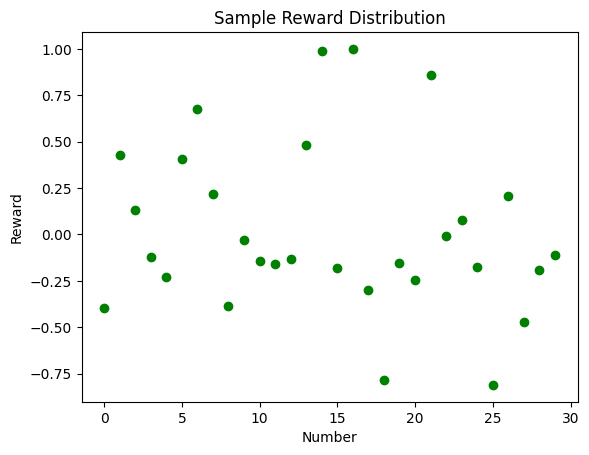

,0
Number of States,101
Number of Reachable States,101
Number of Paths,5813
Reward Distribution Width,30


,algorithm,total_reward,epsilon,alpha,uncertainty,gamma
0,random,30.997403,-,-,-,-
1,epsilongreedy,89.790034,0.1,0.1,-,-
2,ucb,91.842332,-,0.1,0.1,-
3,thompson,46.507054,-,-,-,0.0
4,contextual,378.593938,-,0.9,-,-



=== Game 2/3 ===


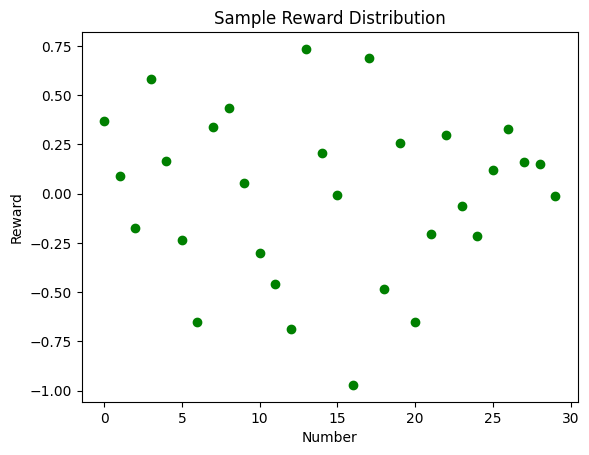

,0
Number of States,101
Number of Reachable States,101
Number of Paths,5988
Reward Distribution Width,30


,algorithm,total_reward,epsilon,alpha,uncertainty,gamma
0,random,-0.493929,-,-,-,-
1,epsilongreedy,121.224265,0.1,0.1,-,-
2,ucb,95.284455,-,0.9,0.7,-
3,thompson,59.002139,-,-,-,0.8
4,contextual,575.847898,-,0.9,-,-



=== Game 3/3 ===


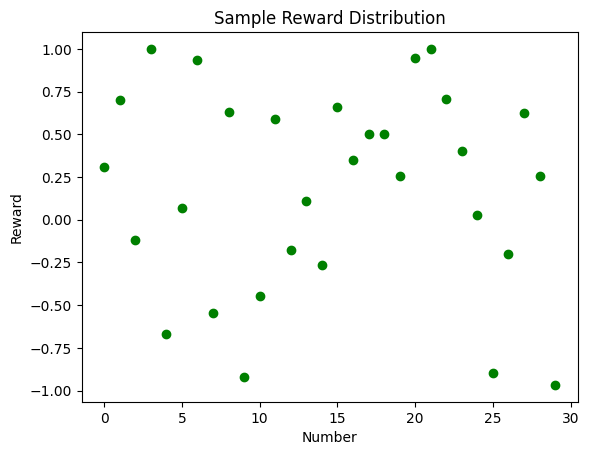

,0
Number of States,101
Number of Reachable States,101
Number of Paths,5574
Reward Distribution Width,30


,algorithm,total_reward,epsilon,alpha,uncertainty,gamma
0,random,44.528739,-,-,-,-
1,epsilongreedy,236.004440,0.1,0.5,-,-
2,ucb,849.717721,-,0.7,0.7,-
3,thompson,76.964985,-,-,-,0.5
4,contextual,922.660748,-,0.9,-,-


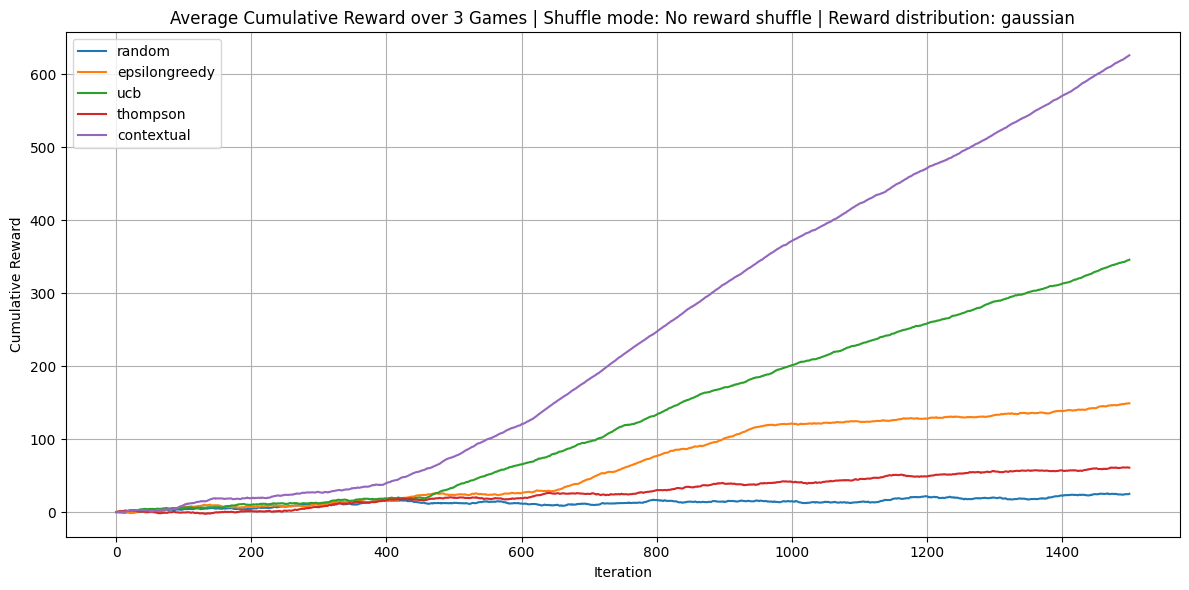

In [11]:
REWARD_DIST_TYPES = [
    'random',           # uniform across [-1, 1]
    'gaussian',         # bell curve around 0
    'skewed_positive',  # biased toward positive rewards
    'skewed_negative',  # biased toward negative rewards
    'bimodal',          # two peaks at ±0.7, rarely neutral
    'sparse',           # 90% zeros, 10% near +1
    'heavy_tailed',     # mostly small, rare extremes
    'constant',         # same fixed reward every time
]

# recompute the reward distributions, introducing non-stationarity
# set to -1 to keep stationary
scramble_step = -1

max_iter = 1500
num_states = 100
reward_dist_width = 30
num_games_to_play = 3
reward_dist_mode = REWARD_DIST_TYPES[1]

epsilon = [0.1, 0.5, 0.7, 0.9, 1]
alpha = [0.1, 0.5, 0.7, 0.9, 1]
uncertainty = [0.1, 0.5, 0.7, 0.9, 1]
gamma = [0,1, 0.5, 0.7, 0.8, 0.95, 1] # apparently, gamma=1 for stationarity because otherwise it will fight against convergence

context_dim = 10


# for labelling...
if scramble_step == -1:
    reward_mode = 'No reward shuffle'
else:
    reward_mode = f'Reward shuffle every {scramble_step} step'

all_histories = {
    "random": [],
    "epsilongreedy": [],
    "ucb": [],
    "thompson": [],
    "contextual": []
}

for game_iter in range(0, num_games_to_play):
    print(f"\n=== Game {game_iter + 1}/{num_games_to_play} ===")

    states = generate_states(num_states, reward_dist_mode, reward_dist_width)

    # uncomment to see sample reward distribution and game statistics
    display(describe_the_game(states).T)

    results, results_df = find_best_configuration(
        ["random", "epsilongreedy", "ucb", "thompson", "contextual"],
        states,
        num_states,
        max_iter,
        scramble_step,
        epsilon,
        alpha,
        uncertainty,
        gamma,
        context_dim,
        lambda_reg=1.0
    )

    display(results_df)

    for alg in all_histories:
        y = [next(iter(entry.values())) for entry in results[alg]['history']]
        all_histories[alg].append(y)

# plot
plt.figure(figsize=(12, 6))
for alg, histories in all_histories.items():
    avg_y = np.mean(histories, axis=0)
    plt.plot(range(len(avg_y)), avg_y, label=alg)

plt.title(f"Average Cumulative Reward over {num_games_to_play} Games | Shuffle mode: {reward_mode} | Reward distribution: {reward_dist_mode}")
plt.xlabel("Iteration")
plt.ylabel("Cumulative Reward")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
